## Setup: Library Imports

We import the core libraries needed throughout the notebook:

- **os**: file and directory path manipulations  
- **pandas** (`pd`): data loading and tabular operations  
- **NumPy** (`np`): numerical arrays and math functions  
- **random**: random sampling and shuffling  
- **Pillow** (`PIL`): image loading and augmentation via `Image` and `ImageEnhance`


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
import pandas as pd
import numpy as np
import random
from PIL import Image, ImageEnhance

## Keras & Utility Imports

We import the components needed to build, train, and preprocess our CNN:

- **`Sequential`**: to stack layers in a linear fashion  
- **`Input, Dense, Flatten, Dropout`**: core building blocks for defining our model architecture  
- **`load_img`, `img_to_array`**: for loading and converting images to NumPy arrays  
- **`Adam`**: the optimizer used during training  
- **`VGG16`**: pre‑trained base model for transfer learning  
- **`shuffle`**: to randomize our dataset paths and labels for unbiased batches  


In [4]:
# keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.preprocessing.image import load_img
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle
from tensorflow.keras.preprocessing.image import img_to_array



Data Loading & Shuffling
**bold text**
We set up our MRI dataset for training and testing by performing the following steps:

**train_dir, test_dir:** Define the file paths to your training and testing image folders.

Collect file paths & labels: Loop through each class folder (e.g., pituitary, glioma, meningioma) to build two lists:

train_paths / test_paths: full paths to each image file.

train_labels / test_labels: the corresponding folder name as the label.

Shuffle: Randomize the order of both paths and labels together using shuffle() to prevent ordering bias during model training and evaluation.

In [5]:
train_dir = '/content/drive/MyDrive/MRI/Training'
test_dir = '/content/drive/MyDrive/MRI/Testing'

#load and shuffle train data

train_paths = []
train_labels = []

for label in os.listdir(train_dir):
  for image in os.listdir(os.path.join(train_dir, label)):
    train_paths.append(os.path.join(train_dir, label, image))
    train_labels.append(label)

# Shuffle the paths and labels together
train_paths, train_labels = shuffle(train_paths, train_labels)

# load and shuffle test data
test_paths = []
test_labels = []

for label in os.listdir(test_dir):
    for image in os.listdir(os.path.join(test_dir, label)):
        test_paths.append(os.path.join(test_dir, label, image))
        test_labels.append(label)

# Shuffle the paths and labels together
test_paths, test_labels = shuffle(test_paths, test_labels)


Random Image Visualization
We randomly sample 10 images from our training set and display them in a 2×5 grid for a quick sanity check. This helps ensure we’re loading the correct images and can visually inspect the variety of tumor cases.

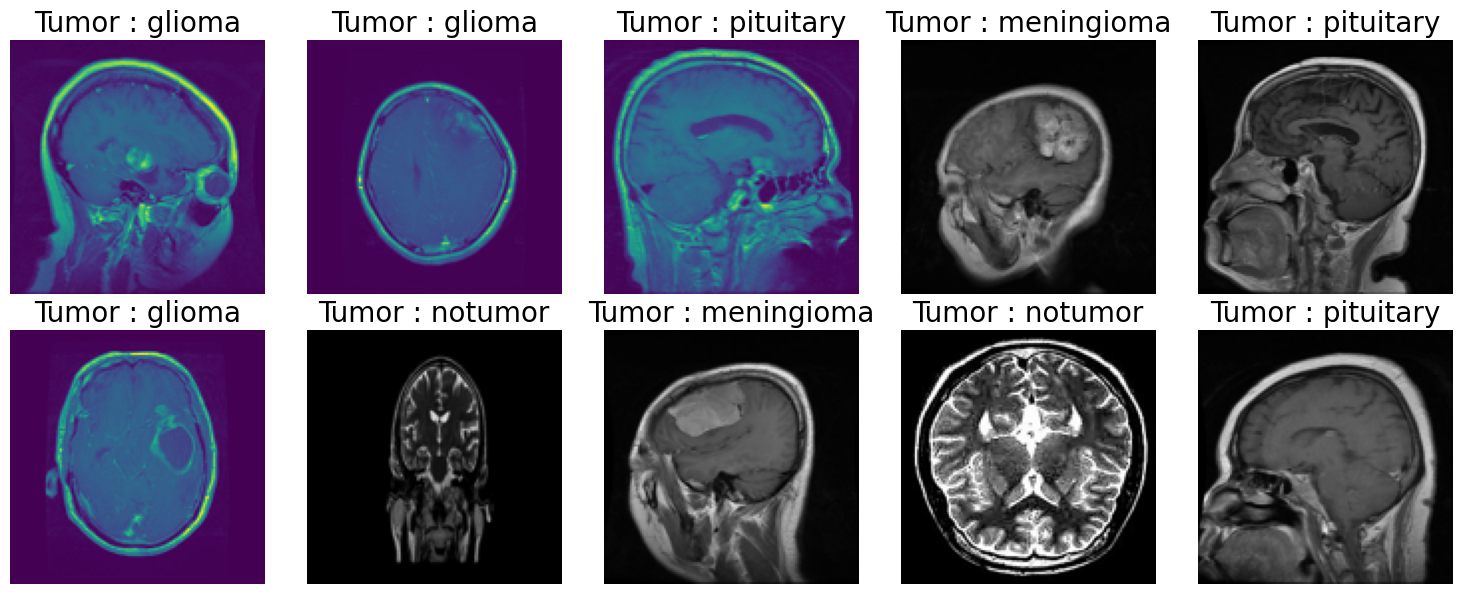

In [6]:
import matplotlib.pyplot as plt

# select random incides for 10 images

random_indices = random.sample(range(len(train_paths)), 10)

# create a figure to display 2 rows
fig, axes = plt.subplots(2,5,figsize = (15,6))
axes = axes.ravel()

# loop through the random indices and display images
for i, index in enumerate(random_indices):
  img_path = train_paths[index]
  img = Image.open(img_path)
  img = img.resize((128,128))

  #display images
  axes[i].imshow(img)
  axes[i].axis('off')

  # set title
  axes[i].set_title(f'Tumor : {train_labels[index]}',fontsize = 20)

plt.tight_layout()
plt.show()

Image Augmentation & Data Generator

We define functions to augment images and to generate batches for training:

augment_image(image): Applies random brightness and contrast adjustments to a NumPy image array, converting to and from a PIL Image for transformations.

open_images(paths): Loads images from given file paths, resizes to (IMAGE_SIZE, IMAGE_SIZE), converts to NumPy arrays, applies augmentation, and collects them into a batch array.

encode_label(labels): Converts string labels into integer indices based on the sorted folder names in train_dir, ensuring consistent label encoding.

datagen(paths, labels, batch_size, epochs): A Python generator that yields (batch_images, batch_labels) tuples for each batch and epoch, where images are augmented and labels are encoded.

In [7]:
# Image Augmentation function

def augment_image(image):
    # Convert array to PIL Image
    image = Image.fromarray(np.uint8(image))

    # Random brightness
    image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))

    # Random contrast
    image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))

    # Convert back to normalized NumPy array
    image = np.array(image) / 255.0
    return image

# Load Images and apply augmentation
def open_images(paths):
    images = []
    for path in paths:
        image = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
        image = img_to_array(image)  # Fix: convert to array before augmentation
        image = augment_image(image)
        images.append(image)
    return np.array(images)

# Encoder labels (convert label names to integer)

def encode_label(labels):
    unique_labels = os.listdir(train_dir)  # Ensure unique labels are determined
    encoded = [unique_labels.index(label) for label in labels]
    return np.array(encoded)

# Data generator for batching
def datagen(paths, labels, batch_size=12, epochs=1):
    for _ in range(epochs):
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i + batch_size]
            batch_images = open_images(batch_paths)
            batch_labels = labels[i:i + batch_size]
            batch_labels = encode_label(batch_labels)
            yield batch_images, batch_labels


Model Definition & Training

We construct our convolutional neural network by leveraging transfer learning with a pre-trained VGG16 base and adding custom classifier layers:

IMAGE_SIZE: Defines the input spatial dimensions (128×128×3).

VGG16 base: Imported without top layers (include_top=False) and pre-loaded with ImageNet weights.

Freezing: All base layers are frozen to retain learned features.

Fine-tuning: The last 5 convolutional layers of VGG16 are unfrozen to adapt to MRI textures.

Classifier head: Includes Flatten(), Dropout(0.3), a hidden dense layer (128 units, ReLU), Dropout(0.2), and a final Dense with softmax over all classes.

Compilation: Uses Adam optimizer (lr=1e-4) and sparse_categorical_crossentropy loss with sparse_categorical_accuracy metric.

Training: Configures batch_size=20, calculates steps_per_epoch, and runs for epochs=6 using our datagen() generator.

In [8]:
IMAGE_SIZE = 128
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3), include_top=False, weights='imagenet')

#freeze all layers of VGG16 base model
for layer in base_model.layers:
    layer.trainable = False

# set only the last few layer
for layer in base_model.layers[-5:]:
    layer.trainable = True

# build a model
model = Sequential()
model.add(Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)))
model.add(base_model)
model.add(Flatten())
model.add(Dropout(0.3))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(len(os.listdir(train_dir)), activation='softmax'))

#compile a model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='sparse_categorical_crossentropy', metrics=['sparse_categorical_accuracy'])

#parametes
batch_size = 20
steps = int(len(train_paths)/batch_size)
epochs = 6

#train model
history = model.fit(datagen(train_paths, train_labels, batch_size=batch_size, epochs=epochs),
                    epochs=epochs, steps_per_epoch=steps)


Epoch 1/6
285/285 ━━━━━━━━━━━━━━━━━━━━ 1111s 4s/step - loss: 0.6400 - sparse_categorical_accuracy: 0.7435
Epoch 2/6
285/285 ━━━━━━━━━━━━━━━━━━━━ 36s 103ms/step - loss: 0.2369 - sparse_categorical_accuracy: 0.9112
Epoch 3/6
285/285 ━━━━━━━━━━━━━━━━━━━━ 29s 102ms/step - loss: 0.1863 - sparse_categorical_accuracy: 0.9243
Epoch 4/6
285/285 ━━━━━━━━━━━━━━━━━━━━ 29s 102ms/step - loss: 0.1307 - sparse_categorical_accuracy: 0.9466
Epoch 5/6
285/285 ━━━━━━━━━━━━━━━━━━━━ 30s 105ms/step - loss: 0.0800 - sparse_categorical_accuracy: 0.9724
Epoch 6/6
285/285 ━━━━━━━━━━━━━━━━━━━━ 29s 101ms/step - loss: 0.0752 - sparse_categorical_accuracy: 0.9723


Training History Visualization

We visualize the model’s training progress by plotting both training accuracy and loss over each epoch:

Figure size: larger for clarity (10×5).

Grid: dashed lines with transparency for better readability.

Markers: circle for accuracy, square for loss to differentiate metrics.

Title and labels: bold title, labeled axes, and epoch ticks.

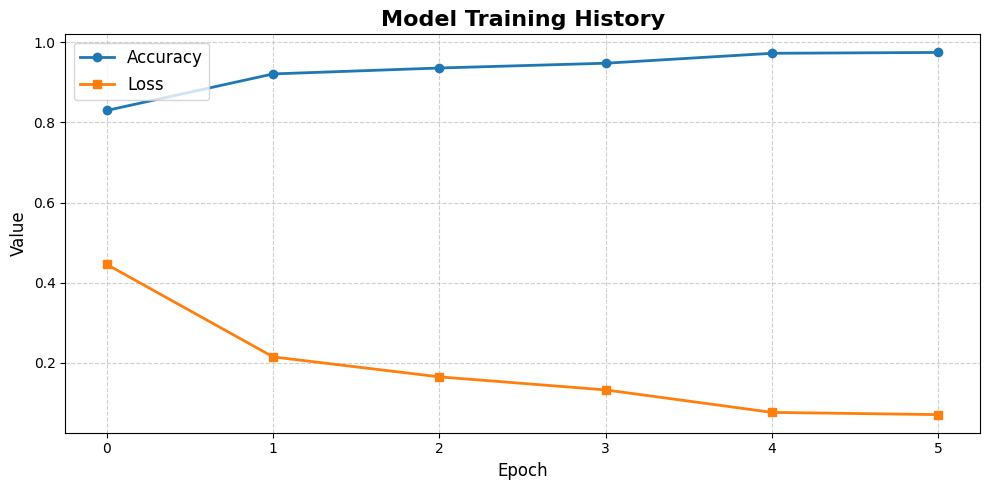

In [9]:
plt.figure(figsize=(10, 5))
plt.grid(linestyle='--', alpha=0.6)

# Plot accuracy with circle markers
plt.plot(
    history.history['sparse_categorical_accuracy'],
    marker='o',
    linewidth=2,
    markersize=6,
    label='Accuracy'
)

# Plot loss with square markers
plt.plot(
    history.history['loss'],
    marker='s',
    linewidth=2,
    markersize=6,
    label='Loss'
)

plt.title('Model Training History', fontsize=16, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.xticks(range(epochs))
plt.legend(loc='upper left', fontsize=12)
plt.tight_layout()
plt.show()

Random Image Visualization

We randomly sample 10 images from our training set and display them in a 2×5 grid for a quick sanity check. This helps ensure we’re loading the correct images and can visually inspect the variety of tumor cases.

In [10]:
from sklearn.metrics import classification_report
import numpy as np

# 1. Load & encode your test data
test_images = open_images(test_paths)              # Load & (optionally) augment test images
test_labels_encoded = encode_label(test_labels)    # Encode the true labels

# 2. Run inference and get predicted classes
pred_probs = model.predict(test_images)
pred_classes = np.argmax(pred_probs, axis=1)

# 3. Print classification report
print("Classification Report:")
print(classification_report(test_labels_encoded, pred_classes))


41/41 ━━━━━━━━━━━━━━━━━━━━ 12s 184ms/step
Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       300
           1       0.98      0.91      0.94       300
           2       0.98      1.00      0.99       405
           3       0.92      0.92      0.92       306

    accuracy                           0.96      1311
   macro avg       0.96      0.96      0.96      1311
weighted avg       0.96      0.96      0.96      1311



Compute the confusion matrix

    We call confusion_matrix(true_labels, predicted_labels).

    Here, test_labels_encoded are your ground‑truth integer labels, and np.argmax(pred_probs, axis=1) picks the class with highest predicted probability for each test image.

Print the raw matrix

    print(conf_matrix) outputs the 2D array so you can quickly see the counts of true vs. predicted labels in your console.

Set up the plot

    plt.figure(figsize=(8, 6)) creates a new drawing canvas that’s 8″ wide by 6″ tall—big enough for all your labels to fit comfortably.

Draw the heatmap

    sns.heatmap(...) turns your confusion‑matrix array into a colored grid:

        annot=True writes each integer count into its cell.

        fmt="d" ensures the annotations are formatted as decimal integers (not floats).

        cmap="Blues" chooses a blue color gradient.

        xticklabels=os.listdir(train_dir) and yticklabels=os.listdir(train_dir) pull your folder (class) names from the training directory so that the axes show human‑readable labels instead of just numbers.

Label the axes and title

    plt.title("Confusion Matrix") adds an overarching title.

    plt.xlabel("Predicted Labels") and plt.ylabel("True Labels") make it clear which axis is which.

Render the plot

    Finally, plt.show() draws everything in your notebook so you can visually assess which classes are being confused most often.

Confusion Matrix:
[[297   0   1   2]
 [  0 274   3  23]
 [  0   0 405   0]
 [ 14   7   4 281]]


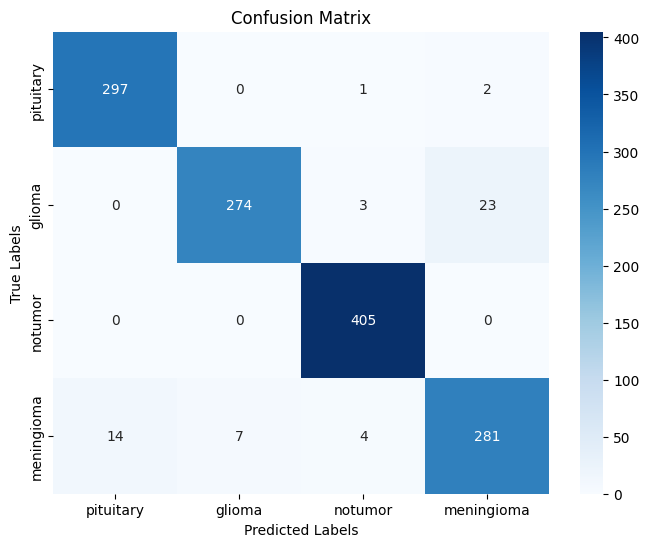

In [15]:
# 3. Confusion Matrix
conf_matrix = confusion_matrix(test_labels_encoded, np.argmax(pred_probs, axis=1))
print("Confusion Matrix:")
print(conf_matrix)

# Plot the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=os.listdir(train_dir), yticklabels=os.listdir(train_dir))
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

## ROC Curve & AUC for Multi‑class MRI Classification

Here we evaluate the model’s performance across all tumor classes by computing the Receiver Operating Characteristic (ROC) curve and the Area Under the Curve (AUC) for each class:

1. **Binarize** the true labels (`label_binarize`) to one‑vs‑all format.  
2. Use `roc_curve` & `auc` to compute each class’s false positive rate (FPR), true positive rate (TPR), and AUC score.  
3. **Plot** all ROC curves on a single figure, plus the diagonal “chance” line.


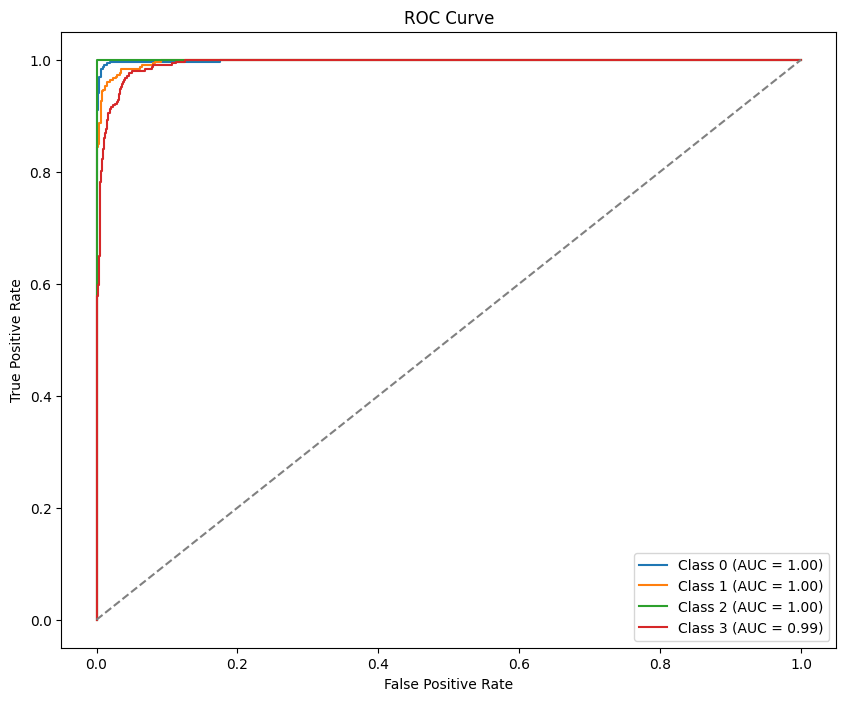

In [16]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
# 4. ROC Curve and AUC
# Binarize the test labels and predictions for multi-class ROC
test_labels_bin = label_binarize(test_labels_encoded, classes=np.arange(len(os.listdir(train_dir))))
test_predictions_bin = pred_probs  # The predicted probabilities for each class

# Compute ROC curve and ROC AUC for each class
fpr, tpr, roc_auc = {}, {}, {}
for i in range(len(os.listdir(train_dir))):
    fpr[i], tpr[i], _ = roc_curve(test_labels_bin[:, i], test_predictions_bin[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Plot ROC curve
plt.figure(figsize=(10, 8))
for i in range(len(os.listdir(train_dir))):
    plt.plot(fpr[i], tpr[i], label=f'Class {i} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='gray')  # Diagonal line
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

## Load the Trained Model

Here we load our previously trained and saved Keras model (`mrimodel.h5`) so we can use it for inference on new MRI scans.


In [17]:
model.save('mrimodel.h5')

load model using keras

In [22]:
from tensorflow.keras.models import load_model
# Load the trained model
model = load_model('mrimodel.h5')

## Tumor Detection & Visualization

The `detect_and_display` helper does the following:

1. **Loads** an image from disk and **resizes** it to the model’s input size (default 128×128).
2. **Normalizes** pixel values to the [0,1] range.
3. **Runs** the pre‑trained `model.predict(...)` to get class probabilities.
4. **Selects** the highest‑confidence class:
   - If that class is `"notumor"`, it labels the image **No Tumor**.
   - Otherwise, it labels it **Tumor: <class>**.
5. **Displays** the original image with a title showing the predicted label and confidence percentage.
6. **Catches** and prints any errors during loading or prediction.

In [19]:
from keras.preprocessing.image import load_img, img_to_array
import numpy as np
import matplotlib.pyplot as plt

# Class labels
class_labels = ['pituitary', 'glioma', 'notumor', 'meningioma']

def detect_and_display(img_path, model, image_size=128):
    """
    Function to detect tumor and display results.
    If no tumor is detected, it displays "No Tumor".
    Otherwise, it shows the predicted tumor class and confidence.
    """
    try:
        # Load and preprocess the image
        img = load_img(img_path, target_size=(image_size, image_size))
        img_array = img_to_array(img) / 255.0  # Normalize pixel values
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Make a prediction
        predictions = model.predict(img_array)
        predicted_class_index = np.argmax(predictions, axis=1)[0]
        confidence_score = np.max(predictions, axis=1)[0]

        # Determine the class
        if class_labels[predicted_class_index] == 'notumor':
            result = "No Tumor"
        else:
            result = f"Tumor: {class_labels[predicted_class_index]}"

        # Display the image with the prediction
        plt.imshow(load_img(img_path))
        plt.axis('off')
        plt.title(f"{result} (Confidence: {confidence_score * 100:.2f}%)")
        plt.show()

    except Exception as e:
        print("Error processing the image:", str(e))

## Predict & Visualize a Single MRI Scan

Here we run our `detect_and_display` helper on a new test image.  
It will load, preprocess, predict, and display the MRI with its predicted label and confidence score.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


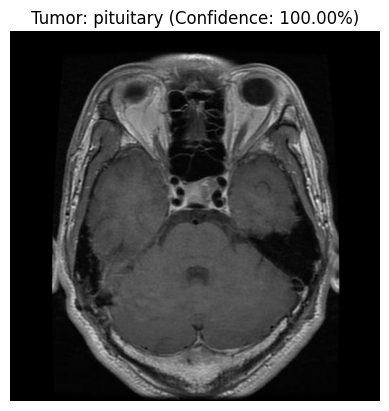

In [21]:
image_path = '/content/drive/MyDrive/MRI/Testing/pituitary/Te-piTr_0000.jpg'  # Provide the path to your new image
detect_and_display(image_path, model)